# Netflix Data Analysis And Visulisation 

This project analyzes a dataset of 8,807 Netflix titles (movies and TV shows) to uncover trends in content type, genre, release patterns, ratings, and geographic distribution. The dataset includes attributes such as title, director, cast, country of production, date added to Netflix, release year, content rating, duration, and genre listings. Using Python (Pandas, NumPy) for data cleaning and exploratory analysis, and Matplotlib/Seaborn for visualization.

In [89]:
!pip install wordcloud

In [90]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime
from wordcloud import WordCloud   

### Data Loading & Preview :

In [2]:
df = pd.read_csv('netflix_movies.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

### Insights : 
- We have 8807 entities. Any column which contains less than 8807 entities contains missing values [director, cast, country, date_added, rating, duration].

- Data Type Inconsitency in date_added column. Ideally, it should be of datatime type but currently it is of object type.

- Number of features is 12

### Data Cleaning & Transformation : 

In [5]:
#checking and cleaning the null values 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
# handle the missing values in  'director' and 'cast' column 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [7]:
#handle the missing values in 'country' using mode (most frequent entry)
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)

In [8]:
#handle the 'date_added' 'rating' 'duration' columns  
df.dropna(subset=['date_added','rating','duration'], inplace=True) # as the null values in these col are very less(.02%),dropping them

**Transformations**

In [9]:
# Converting the "date_added" col to datetime data type.
df['date_added'] = pd.to_datetime(df['date_added'],format = 'mixed',dayfirst = False)
#used format = mixed to handle variations in date format 

In [10]:
# creating month and year columns 
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [11]:
# verifying the cleaning & transformations 
print("Missing values after cleaning : ")
print(df.isnull().sum())

print("/nData types after transformation: ")
print(df.dtypes)

Missing values after cleaning : 
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64
/nData types after transformation: 
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


### Data Cleaning & Preprocessing
- Removed/imputed missing values across all columns (director, cast, country, date_added, rating, duration) — dataset now has 0 nulls in every column.
- Converted `date_added` from object to `datetime64[ns]` using `pd.to_datetime()` for time-based analysis.
- Extracted `year_added` and `month_added` as new integer columns from `date_added` to enable trend analysis over time.
- Verified final data types and null counts to confirm the dataset is clean and analysis-ready.

### Exploratory Data Analysis : 

- Distribution of content tyoe 

In [12]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


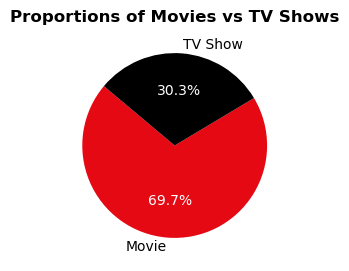

In [23]:
#visualising the findings
plt.figure(figsize=(3,3))
wedges, texts, autotexts = plt.pie(
    type_counts, 
    labels=type_counts.index,
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#E50914', '#000000']
)

plt.setp(autotexts, color='white')
plt.title("Proportions of Movies vs TV Shows",fontweight = 'bold')
plt.show()

### Insight: Content Type Distribution

- Netflix's catalog is heavily skewed toward Movies, which make up 69.7% of all titles, compared to 30.3% for TV Shows. 
- This roughly 7:3 ratio suggests Netflix's content acquisition/production strategy has historically favored movies.

In [24]:
# group data by year and content type 
content_overtime = df.groupby(['year_added','type']).size().unstack().fillna(0)
print(content_overtime)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


**Visualisation**

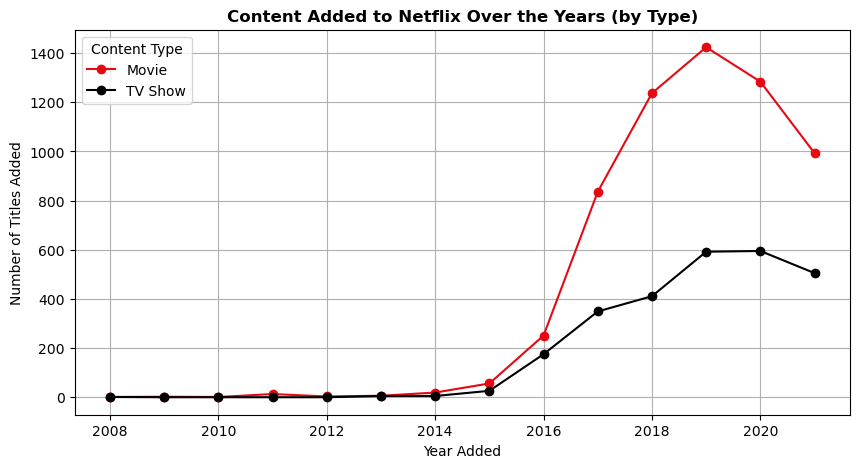

In [32]:
content_overtime.plot(kind='line', marker='o', figsize=(10, 5), color=['#E50914', '#000000'])
plt.title('Content Added to Netflix Over the Years (by Type)', fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

### Insight:
- By separating movies and TV shows, we can clearly see that while both grew significantly from the year 2008 to 2020, the addition of movies accelerated more dramatically, especially in the year 2019.
- The growth in the TV Shows segment is rather steady.
- after 2019 we see a dip in content addition in both of the segments,which might be due the rise of COVID-19 during the time which might have affected the production.

**Finding the Most Popular Genre**

In [34]:
genres = df.assign(genre = df['listed_in'].str.split(', ')).explode('genre')
genres.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows


- **Top 15 Popular Genre & their counts**

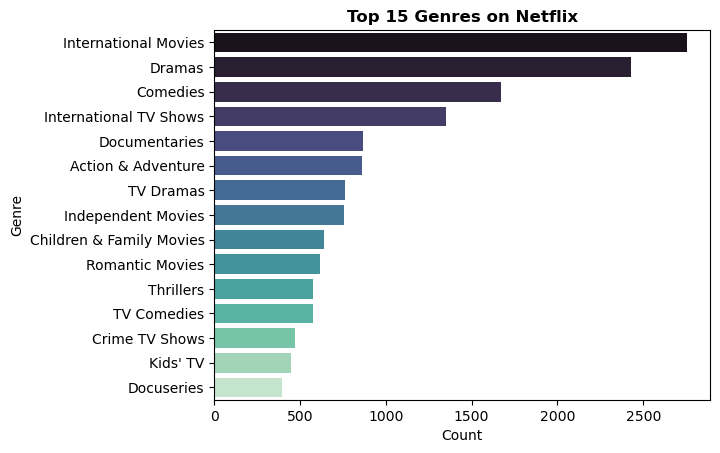

In [64]:
# top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()

# Rename columns for clarity
top_genres_counts.columns = ['genre', 'count']

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix',fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

### Insights 
- International Movies is the most dominated genre which explains Netflix's global content stratergy.

-- Distribution of Content by duration --

In [40]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [43]:
# Clean and convert duration for movies
movies_df['duration_min' ] = movies_df['duration' ]. str.replace(' min', '').astype(int)

# Clean and convert duration for TV shows 
tv_shows_df['seasons' ] = tv_shows_df['duration']. str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

C:\Users\ariji\AppData\Local\Temp\ipykernel_14032\2660563000.py:8: UserWarning: 
The palette list has fewer values (6) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


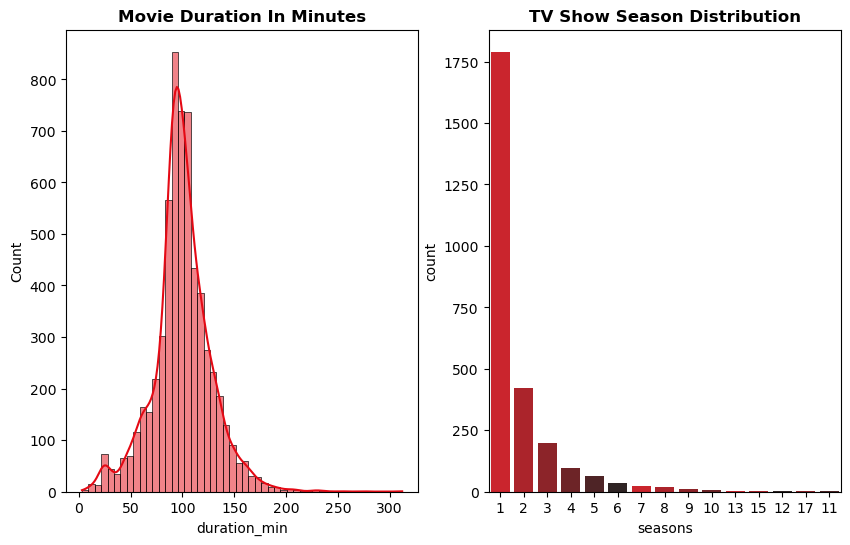

In [63]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='#E50914').set_title('Movie Duration In Minutes',fontweight='bold')

# TV Show Season Distribution
sns.countplot(
    ax=axes[1], 
    x='seasons', 
    data=tv_shows_df, 
    hue='seasons', 
    order=tv_shows_df['seasons'].value_counts().index,
    palette=sns.dark_palette('#E50914', reverse=True),
    legend=False
)
axes[1].set_title('TV Show Season Distribution',fontweight='bold')

plt.show()

### Movie Duration Disribution
- Peaks sharply around 90–100 minutes (850 titles) which is the the most common runtime on Netflix
- Right-skewed distribution: fast rise from 50 min to the peak, then a long tail out to 250–300 min (a small number of outlier films, likely epics/extended documentaries)
- Small secondary bump around 20–30 minutes, suggesting a minor segment of short-form content (specials/shorter films) separate from the main cluster
- Overall: Netflix's movie catalog is centered on standard 90–110 min feature-length runtimes
  
### TV Show Seasons Distribution
- Steep drop-off pattern: 1,750+ shows have just 1 season, over 4x the next category (season 2, 425 shows)
- By season 3, count falls below 200; by season 5, under 100.
- Distribution flattens near zero from season 6 onward, with only a few shows reaching double-digit seasons (up to 17)
- Indicates Netflix favors limited/single-season series over long-running shows may be  likely to diversify content and reduce renewal risk, unlike traditional network TV.

### Where does most content come from ?

In [60]:
# Handle the multi-country listings 
countries = df. assign(country=df['country' ]. str.split( ', ')).explode('country')

# Get the top 15 countries and their counts
top_countries_counts = countries['country' ] . value_counts () .reset_index()
top_countries_counts. columns = ['country', 'count'] 
print(top_countries_counts)

            country  count
0     United States   4509
1             India   1046
2    United Kingdom    803
3            Canada    445
4            France    393
..              ...    ...
122         Bermuda      1
123         Ecuador      1
124         Armenia      1
125        Mongolia      1
126      Montenegro      1

[127 rows x 2 columns]


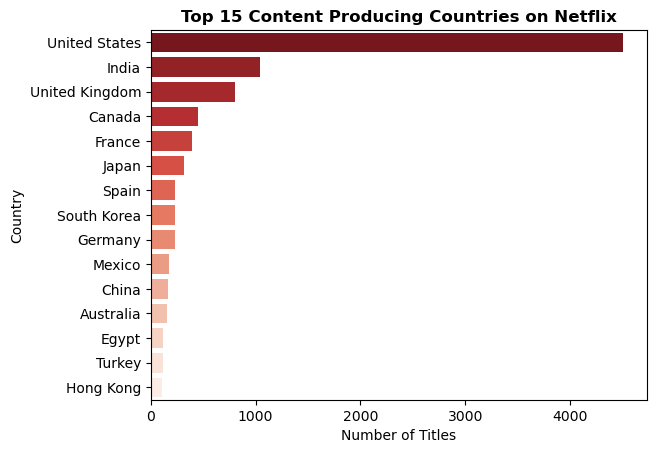

In [66]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts . head (15)

sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='Reds_r', hue='country', legend=False) 
plt.title('Top 15 Content Producing Countries on Netflix',fontweight='bold') 
plt.xlabel('Number of Titles') 
plt.ylabel('Country') 
plt. show()

**Insights** : 
- The US is by far the largest producer of the content available on Netflix followed by India which somehow explains that why so many of the top actors were from India.

### Maturity ratings of the contents :

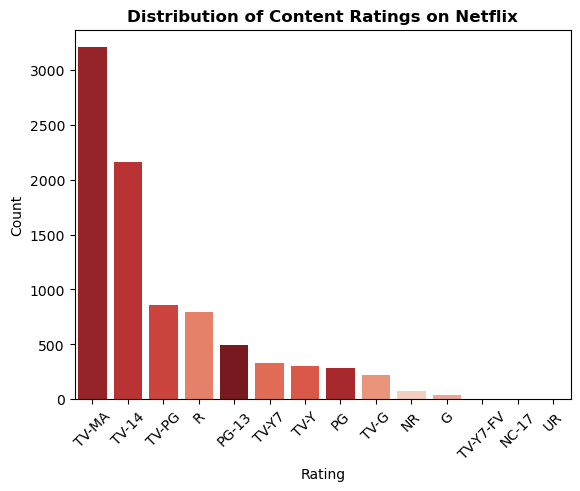

In [70]:
sns.countplot(x='rating', data=df, order=df['rating' ]. value_counts() . index, palette='Reds_r', hue='rating')
plt. title('Distribution of Content Ratings on Netflix',fontweight = 'bold')
plt.xlabel('Rating') 
plt.ylabel('Count')
plt.xticks(rotation=45) 
plt. show()

**Insight:**
- A large portion of the Netflix content aimed at mature audiences, with TV-MA (Mature Audience) and TV-14 (Parents Strongly Cautioned) being the two most common ratings.

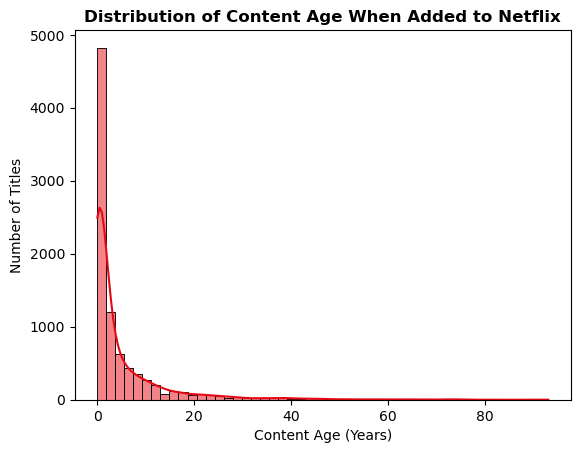

In [82]:
# Creating the 'age_on_netflix' feature 
df['age_on_netflix'] = df['year_added' ] - df['release_year' ]

# Filtering  out any potential errors where added year is before release_year 
content_age = df[df['age_on_netflix' ] >= 0]

sns.histplot(data=content_age, x='age_on_netflix',bins=50, kde=True,color='#E50914') 
plt.title('Distribution of Content Age When Added to Netflix',fontweight = 'bold') 
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles') 
plt.show()

**Insight:**
- The large spike at 0 indicates that the significant amount of content is being added in the same year, which is the characterstic of the "Netflix Originals". However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decaded old, building a deep library of classic films and TV shows.

### Multi-Variate Analysis :

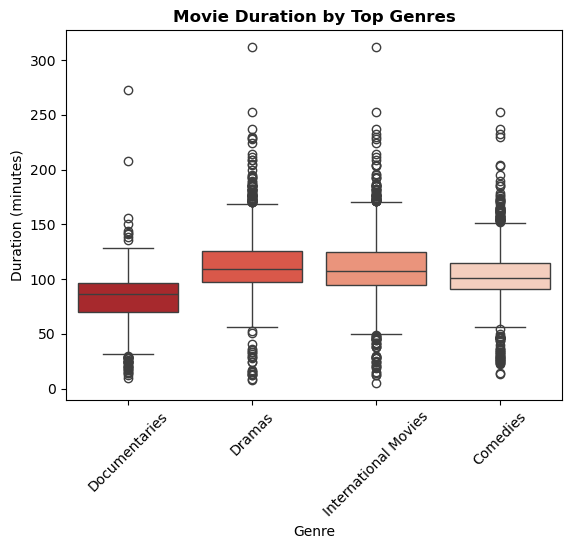

In [86]:
# Analyze movie duration across different top genres
top_genres = genres['genre' ].value_counts() .index [ :5]
genres_movies = genres[(genres['type' ] == 'Movie') & (genres['genre' ].isin(top_genres))].copy()
genres_movies ['duration_min' ] = genres_movies[ 'duration' ] . str. replace( ' min', '') . astype(int)

sns. boxplot(data=genres_movies, x='genre', y='duration_min', palette='Reds_r', hue='genre', legend=False) 
plt.title('Movie Duration by Top Genres',fontweight='bold')
plt.xlabel('Genre') 
plt.ylabel('Duration (minutes)') 
plt.xticks(rotation=45) 
plt.show()

**Insight:**
- Dramas & Internaiton Movies have more outliers and reflects the diverse filmmaking styles around the world.

### Word Cloud from the content description :

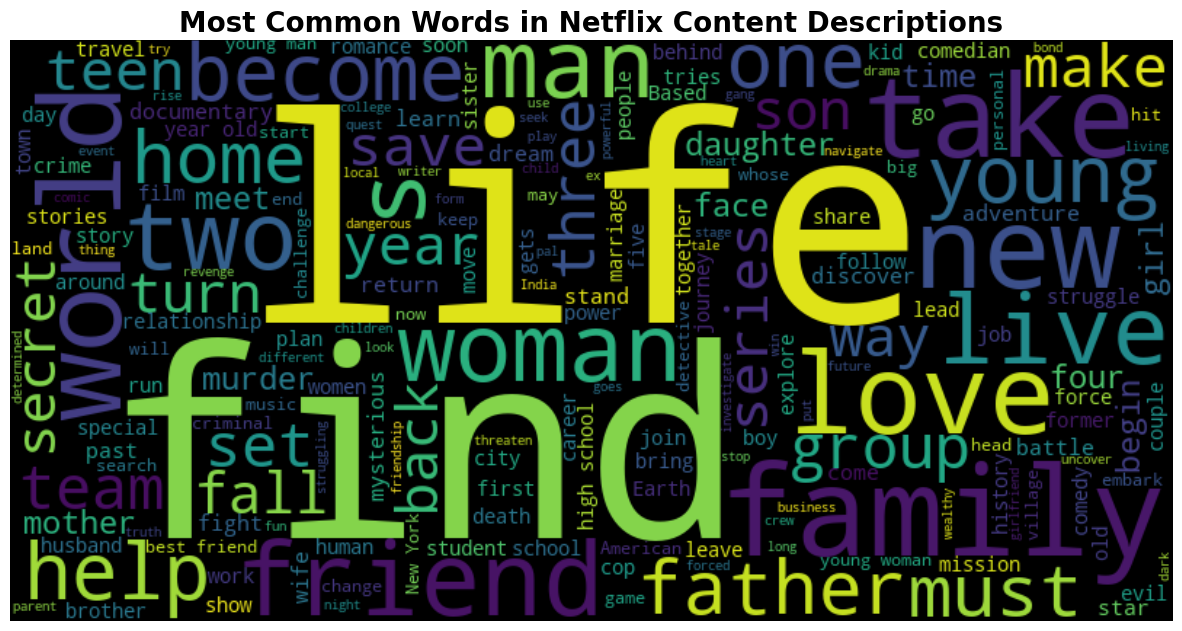

In [94]:
# Combining  all descriptions into a single string
text = ''.join(df['description' ])
# Creating and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black' ) . generate(text)

# Display the generated image 
plt.figure(figsize=(15, 10)) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20,fontweight = 'bold')
plt.show()

**Insight:**
- The word cloud highlights common themes and subjects. Words like "life,""family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

## KPI's to Include from the analysis : 

In [103]:
total_titles = df.shape[0] # 1. Total Number of Titles
print(f"Total Titles: {total_titles}")

Total Titles: 8790


In [102]:
type_ratio = df['type'].value_counts(normalize=True) * 100 # 2. Movie vs TV Show Ratio (%)
print(type_ratio.round(1))

type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


In [100]:
avg_duration = movies_df['duration_min'].mean() # 3. Average Movie Duration (in minutes)
print(f"Average Movie Duration: {avg_duration:.1f} minutes")

Average Movie Duration: 99.6 minutes


In [101]:
top_country = df['country'].value_counts().idxmax() # 4. Top Content-Producing Country
top_country_count = df['country'].value_counts().max()
print(f"Top Content-Producing Country: {top_country} ({top_country_count} titles)")

Top Content-Producing Country: United States (3638 titles)


### This in-depth EDA of the Netflix dataset has revealed several key characteristics and strategies of the platform's content library.
**Key Findings:**

1. Content Strategy: Netflix's library is movie-heavy (~70%), and the platform aggressively added content between 2016-2019. Their strategy involves a mix of brand new originals (added the same year they are release and a deep library of licensed older content.

2. Global Dominance: While the US is the top content producer, the platform is heavily international, with India being a massive contributor. This is reflected in the top genres ("International Movies") and most frequent actors.

3. Target Audience: The content library is skewed towards mature audiences, with TV-MA and TV-14 being the most common ratings.

4. Content Format & Genre: Dramas and Comedies are universally popular genres. Most movies stick to a standard 90-120 minute runtime, while the vast majority of TV shows only last for a single season, suggest high-risk, high-reward approach to series production.

**Common Themes:** Descriptions of content frequently revolve around universal themes of life, family , love , school and  discovery.

**Limitations:** This dataset is a snapshot in time and lacks viewership data. Therefore, my analysis is of the supply of content, not its demand or popularity.